## Validálás02 - első derivált maximuma

### Légúti kit

In [1]:
from app.pcr.data_loader import eds_extract

covid_01 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_01.eds"
covid_02 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_02.eds"
covid_03 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_03.eds"
covid_04 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_04.eds"
covid_05 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_05.eds"
covid_06 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_06.eds"
covid_07 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_07.eds"
covid_08 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_08.eds"
covid_09 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_09.eds"
covid_10 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\COVID_teszt\\covid_10.eds"
hpv_1 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV\\2015-08-13_kereszt kontam_ism2_plate1_csop1.eds"
df = eds_extract(covid_01)
print(df.head())



dye  well well_position  cycle    CY5    FAM    ROX    VIC
0       1            A1      1  63745  68319  49989  72140
1       1            A1      2  63621  68203  49859  71899
2       1            A1      3  63501  67822  49828  71490
3       1            A1      4  63504  67657  49967  71383
4       1            A1      5  63584  67787  50038  71346


In [2]:
import numpy as np
from scipy.signal import savgol_filter

 
def evaluate_sample_derivate_1_max(cycles,
                 fluorescence,
                 plateau_cycles: int = 10,
                 plateau_std_factor: float = 2.0,
                 dy_mean_threshold: float = 1000.0,
                 window: int = 9,
                 poly: int = 2) -> dict:
    """
    Cycle of Plateau Deviation (CpD) módszer alapján meghatározza,
    hogy egy PCR görbe pozitív vagy negatív, és kiszámolja a Ct értéket.
 
    Negatív/pozitív döntés:
        A simított görbe 1. deriváltjának átlaga meghaladja-e a küszöböt?
        Ha igen → pozitív, visszafelé haladva meghatározza a Ct-t.
        Ha nem  → negatív.
 
    Paraméterek
    -----------
    cycles             : ciklusszámok tömbje (x tengely)
    fluorescence       : fluoreszcencia értékek tömbje (y tengely)
    plateau_cycles     : hány utolsó ciklust használjon plateau-hoz (default: 10)
    plateau_std_factor : hány szórásnyira kell kilépni a plateau-ból (default: 2)
    dy_mean_threshold  : minimális derivált átlag pozitív döntéshez (default: 1000)
    window             : Savitzky-Golay ablakméret (default: 9)
    poly               : Savitzky-Golay polinom fok (default: 2)
 
    Visszatérési érték
    ------------------
    dict:
        result  : "pozitív" vagy "negatív"
        ct      : Ct érték (float), vagy None ha negatív
    """
 
    y_smooth = savgol_filter(fluorescence, window, poly)
    dy = savgol_filter(y_smooth, window, poly, deriv=1)
    dy_1_max = dy.max()
    return dy_1_max

In [3]:
import pandas as pd

files = [covid_01, covid_02, covid_03, covid_04, covid_05, covid_06, covid_07, covid_08, covid_09, covid_10]

leguti_der1_max = pd.DataFrame()
for file in files:
    df = eds_extract(file)
    rows = []
    channels = ["FAM", "VIC", "CY5", 'ROX']

    for wp in df['well_position'].unique():
        wp_df = df[df['well_position'] == wp]
        cycles = wp_df['cycle'][9:].values
        row = {'well_position': wp}
 
        for ch in channels:
            fluorescence = wp_df[ch][9:].values
            sample_result = evaluate_sample_derivate_1_max(cycles, fluorescence, window=9)
            row[ch] = sample_result
 
        rows.append(row)
 
    result = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
    result['PCR'] = file.split("\\")[-1].split(".")[0]
    leguti_der1_max_result = pd.concat([leguti_der1_max, result], ignore_index=True)

leguti_der1_max_result.head()

,well_position,FAM,VIC,CY5,ROX,PCR
0,A1,64.903680,7607.101732,159.722150,622.481385,covid_10
1,A3,85.714724,7316.513997,181.616811,590.518254,covid_10
2,A5,139.361438,7190.490404,179.482973,593.693146,covid_10
3,A7,84.173773,6199.694012,218.507515,516.555700,covid_10
4,A9,85.480911,6110.914069,194.313458,540.406061,covid_10


In [4]:
leguti_der1_max_result = leguti_der1_max_result.melt(id_vars=['PCR', 'well_position'], var_name='dye', value_name='dy_1_max')
leguti_der1_max_result.head()

,PCR,well_position,dye,dy_1_max
0,covid_10,A1,FAM,64.903680
1,covid_10,A3,FAM,85.714724
2,covid_10,A5,FAM,139.361438
3,covid_10,A7,FAM,84.173773
4,covid_10,A9,FAM,85.480911


In [5]:
leguti_manual = pd.read_excel("C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\Szakdolgozat\\260420_manulis_ertekeles.xlsx")
leguti_manual_curves = leguti_manual.drop(columns=["minta", "target"], axis=1)
leguti_manual_curves_melted = leguti_manual_curves.melt(id_vars=["well_position", "PCR"], var_name="dye", value_name="leguti_manual")

In [6]:
leguti_der1_max = pd.merge(leguti_der1_max_result, leguti_manual_curves_melted, on=["PCR", "well_position", "dye"], how="left")
leguti_der1_max.head(10)

,PCR,well_position,dye,dy_1_max,leguti_manual
0,covid_10,A1,FAM,64.903680,negatív
1,covid_10,A3,FAM,85.714724,negatív
2,covid_10,A5,FAM,139.361438,negatív
3,covid_10,A7,FAM,84.173773,negatív
4,covid_10,A9,FAM,85.480911,negatív
5,covid_10,C1,FAM,34.792569,negatív
6,covid_10,C3,FAM,94.283058,negatív
7,covid_10,C5,FAM,18462.472439,pozitív
8,covid_10,C7,FAM,82.711652,negatív
9,covid_10,C9,FAM,61.765296,negatív


In [7]:
leguti_der1_max[leguti_der1_max['well_position']== 'M9']

,PCR,well_position,dye,dy_1_max,leguti_manual


In [8]:
import plotly.express as px

fig = px.box(
    leguti_der1_max,
    x="leguti_manual",
    y="dy_1_max",
    color="dye",
    color_discrete_map={
        "FAM": "#D75656",
        "ROX": "#7DA78C",
        "CY5": "#744577",
        "VIC": "#6594B1"
    }
)

fig.update_layout(
    template="simple_white",
    width=600,
    height=600,
    xaxis_title="Manuális értékelés",
    yaxis_title="Érték",
    yaxis=dict(range=[-1000, 70000])
)

fig.update_layout(
    title=dict(
        text="Első derivált maximuma Légúti kitben csatornák szerint",
        x=0.5
    )
)

fig.add_hline(
    y=1100,
    line_dash="dash",
    line_color="gray",
    annotation_text="threshold",
    annotation_position="top left")

fig.add_shape(
    type="line",
    xref="paper",   # ← EZ A LÉNYEG
    x0=0,
    x1=1,
    yref="y",
    y0=3000,
    y1=3000,
    line=dict(color="gray", width=2, dash="dash"))


fig.show()

### HPV kit

In [9]:
from app.pcr.data_loader import eds_extract


hpv_1 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_1.eds"
hpv_2 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_2.eds"
hpv_3 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_3.eds"
hpv_4 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_4.eds"
hpv_5 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_5.eds"
hpv_6 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_6.eds"
hpv_7 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_7.eds"
hpv_df = eds_extract(hpv_2)
hpv_df.to_excel("C:\\Users\\anett\\Downloads\\hpv_teszt_2.xlsx", index=False)
print(hpv_df.head())

dye  well well_position  cycle    CY5     FAM     VIC
0       1            A1      1  33294  365294  262174
1       1            A1      2  32800  362112  259326
2       1            A1      3  31772  356887  254004
3       1            A1      4  30616  347854  247097
4       1            A1      5  29532  336745  239351


In [10]:
import pandas as pd


hpv_files = [hpv_1, hpv_2, hpv_3, hpv_4, hpv_5, hpv_6, hpv_7]
#hpv_files = [hpv_3]

hpv_der1_max = pd.DataFrame()
for hpv_file in hpv_files:
    df_hpv = eds_extract(hpv_file)
    rows = []
    channels = ["FAM", "VIC", "CY5"]

    for wp in df_hpv['well_position'].unique():
        wp_df = df_hpv[df_hpv['well_position'] == wp]
        cycles = wp_df['cycle'][9:].values
        row = {'well_position': wp}
 
        for ch in channels:
            fluorescence = wp_df[ch][9:].values
            sample_result = evaluate_sample_derivate_1_max(cycles, fluorescence, window=9)
            row[ch] = sample_result
 
        rows.append(row)
 
    result_hpv = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
    result_hpv['PCR'] = hpv_file.split("\\")[-1].split(".")[0]
    hpv_der1_max = pd.concat([hpv_der1_max, result_hpv], ignore_index=True)


In [11]:
hpv_der1_max_melted = hpv_der1_max.melt(id_vars=['PCR', 'well_position'], var_name='dye', value_name='dy_1_max')
hpv_der1_max_melted.head()

,PCR,well_position,dye,dy_1_max
0,hpv_teszt_1,A1,FAM,166.566157
1,hpv_teszt_1,A11,FAM,245.918952
2,hpv_teszt_1,A13,FAM,279.243506
3,hpv_teszt_1,A15,FAM,177.668297
4,hpv_teszt_1,A17,FAM,303.759452


In [12]:
hpv_manual_result = pd.read_excel("C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\Szakdolgozat\\260425_manulis_ertekeles_hpv.xlsx")
hpv_manual_result_curves = hpv_manual_result.drop(columns=["minta", "target"], axis=1)
hpv_manual_result_curves_melted = hpv_manual_result_curves.melt(id_vars=["well_position", "PCR"], var_name="dye", value_name="manual_result")
hpv_manual_result_curves_melted.head()

,well_position,PCR,dye,manual_result
0,A1,hpv_teszt_1,FAM,negatív
1,A11,hpv_teszt_1,FAM,negatív
2,A13,hpv_teszt_1,FAM,negatív
3,A15,hpv_teszt_1,FAM,negatív
4,A17,hpv_teszt_1,FAM,negatív


In [13]:
hpv_der1_max_result = pd.merge(hpv_der1_max_melted, hpv_manual_result_curves_melted, on=["PCR", "well_position", "dye"], how="left")
hpv_der1_max_result.head()

,PCR,well_position,dye,dy_1_max,manual_result
0,hpv_teszt_1,A1,FAM,166.566157,negatív
1,hpv_teszt_1,A11,FAM,245.918952,negatív
2,hpv_teszt_1,A13,FAM,279.243506,negatív
3,hpv_teszt_1,A15,FAM,177.668297,negatív
4,hpv_teszt_1,A17,FAM,303.759452,negatív


In [14]:
hpv_der1_max_result[hpv_der1_max_result['well_position']== 'O21']

,PCR,well_position,dye,dy_1_max,manual_result
90,hpv_teszt_1,O21,FAM,537.673584,negatív
186,hpv_teszt_2,O21,FAM,1838.309083,negatív
282,hpv_teszt_3,O21,FAM,264.379569,negatív
378,hpv_teszt_4,O21,FAM,293.040909,negatív
474,hpv_teszt_5,O21,FAM,163.742929,negatív
570,hpv_teszt_6,O21,FAM,112.411688,negatív
666,hpv_teszt_7,O21,FAM,148.513564,negatív
762,hpv_teszt_1,O21,VIC,1117.288760,negatív
858,hpv_teszt_2,O21,VIC,1252.366890,negatív
954,hpv_teszt_3,O21,VIC,268.165356,negatív


In [15]:
import plotly.express as px

fig = px.box(
    hpv_der1_max_result, 
    x="manual_result",
    y="dy_1_max",
    color="dye",
    color_discrete_map={
        "FAM": "#D75656",
        "ROX": "#7DA78C",
        "CY5": "#744577",
        "VIC": "#6594B1"
    }
)

fig.update_layout(
    template="simple_white",
    width=600,
    height=600,
    xaxis_title="Manuális értékelés",
    yaxis_title="Érték",
    yaxis=dict(range=[-1000, 70000])
)

fig.update_layout(
    title=dict(
        text="Első derivált maximuma Légúti kitben csatornák szerint",
        x=0.5
    )
)

fig.add_hline(
    y=1100,
    line_dash="dash",
    line_color="gray",
    annotation_text="threshold",
    annotation_position="top left")

fig.add_shape(
    type="line",
    xref="paper",   # ← EZ A LÉNYEG
    x0=0,
    x1=1,
    yref="y",
    y0=3000,
    y1=3000,
    line=dict(color="gray", width=2, dash="dash"))


fig.show()

## Validálás02 - első derivált átlaga

In [16]:
import numpy as np
from scipy.signal import savgol_filter

 
def evaluate_sample_new(cycles,
                 fluorescence,
                 plateau_cycles: int = 10,
                 plateau_std_factor: float = 2.0,
                 dy_mean_threshold: float = 1000.0,
                 window: int = 9,
                 poly: int = 2) -> dict:
    """
    Cycle of Plateau Deviation (CpD) módszer alapján meghatározza,
    hogy egy PCR görbe pozitív vagy negatív, és kiszámolja a Ct értéket.
 
    Negatív/pozitív döntés:
        A simított görbe 1. deriváltjának átlaga meghaladja-e a küszöböt?
        Ha igen → pozitív, visszafelé haladva meghatározza a Ct-t.
        Ha nem  → negatív.
 
    Paraméterek
    -----------
    cycles             : ciklusszámok tömbje (x tengely)
    fluorescence       : fluoreszcencia értékek tömbje (y tengely)
    plateau_cycles     : hány utolsó ciklust használjon plateau-hoz (default: 10)
    plateau_std_factor : hány szórásnyira kell kilépni a plateau-ból (default: 2)
    dy_mean_threshold  : minimális derivált átlag pozitív döntéshez (default: 1000)
    window             : Savitzky-Golay ablakméret (default: 9)
    poly               : Savitzky-Golay polinom fok (default: 2)
 
    Visszatérési érték
    ------------------
    dict:
        result  : "pozitív" vagy "negatív"
        ct      : Ct érték (float), vagy None ha negatív
    """
 
    y_smooth = savgol_filter(fluorescence, window, poly)
    dy = savgol_filter(y_smooth, window, poly, deriv=1)
    dy_mean = dy.mean()
    return dy_mean

In [17]:
import pandas as pd

files = [covid_01, covid_02, covid_03, covid_04, covid_05, covid_06, covid_07, covid_08, covid_09, covid_10]

all_result = pd.DataFrame()
for file in files:
    df = eds_extract(file)
    rows = []
    channels = ["FAM", "VIC", "CY5", "ROX"]

    for wp in df['well_position'].unique():
        wp_df = df[df['well_position'] == wp]
        cycles = wp_df['cycle'][9:].values
        row = {'well_position': wp}
 
        for ch in channels:
            fluorescence = wp_df[ch][9:].values
            sample_result = evaluate_sample_new(cycles, fluorescence, window=9)
            row[ch] = sample_result
 
        rows.append(row)
 
    result = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
    result['PCR'] = file.split("\\")[-1].split(".")[0]
    all_result = pd.concat([all_result, result], ignore_index=True)

all_result.head()

,well_position,FAM,VIC,CY5,ROX,PCR
0,A1,-64.914202,1536.127813,154.325537,297.587277,covid_01
1,A11,-75.514159,1718.092690,145.157051,294.564519,covid_01
2,A13,-50.864883,1569.107503,150.624639,286.718197,covid_01
3,A15,-74.851208,1660.808902,138.308082,288.291042,covid_01
4,A17,-42.495349,1547.689848,137.867387,272.201084,covid_01


In [18]:
all_result_melted = all_result.melt(id_vars=['PCR', 'well_position'], var_name='dye', value_name='dy_mean')
all_result_melted.head()

,PCR,well_position,dye,dy_mean
0,covid_01,A1,FAM,-64.914202
1,covid_01,A11,FAM,-75.514159
2,covid_01,A13,FAM,-50.864883
3,covid_01,A15,FAM,-74.851208
4,covid_01,A17,FAM,-42.495349


In [19]:
manual_result = pd.read_excel("C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\Szakdolgozat\\260420_manulis_ertekeles.xlsx")
manual_result.head()

,PCR,well_position,FAM,VIC,CY5,ROX,minta,target
0,covid_10,A1,negatív,pozitív,negatív,negatív,negatív,NaN
1,covid_10,A3,negatív,pozitív,negatív,negatív,negatív,NaN
2,covid_10,A5,negatív,pozitív,negatív,negatív,negatív,NaN
3,covid_10,A7,negatív,pozitív,negatív,negatív,negatív,NaN
4,covid_10,A9,negatív,pozitív,negatív,negatív,negatív,NaN


In [20]:
manual_result_curves = manual_result.drop(columns=["minta", "target"], axis=1)
manual_result_curves.head()


,PCR,well_position,FAM,VIC,CY5,ROX
0,covid_10,A1,negatív,pozitív,negatív,negatív
1,covid_10,A3,negatív,pozitív,negatív,negatív
2,covid_10,A5,negatív,pozitív,negatív,negatív
3,covid_10,A7,negatív,pozitív,negatív,negatív
4,covid_10,A9,negatív,pozitív,negatív,negatív


In [21]:
manual_result_curves_melted = manual_result_curves.melt(id_vars=["well_position", "PCR"], var_name="dye", value_name="manual_result")
manual_result_curves_melted.head()

,well_position,PCR,dye,manual_result
0,A1,covid_10,FAM,negatív
1,A3,covid_10,FAM,negatív
2,A5,covid_10,FAM,negatív
3,A7,covid_10,FAM,negatív
4,A9,covid_10,FAM,negatív


In [22]:
all_manual_result = pd.merge(all_result_melted, manual_result_curves_melted, on=["PCR", "well_position", "dye"], how="left")
all_manual_result.head()

,PCR,well_position,dye,dy_mean,manual_result
0,covid_01,A1,FAM,-64.914202,negatív
1,covid_01,A11,FAM,-75.514159,negatív
2,covid_01,A13,FAM,-50.864883,negatív
3,covid_01,A15,FAM,-74.851208,negatív
4,covid_01,A17,FAM,-42.495349,negatív


In [23]:
all_manual_result_no_vic = all_manual_result[all_manual_result['dye'] != 'VIC']
all_manual_result_no_vic.head()

,PCR,well_position,dye,dy_mean,manual_result
0,covid_01,A1,FAM,-64.914202,negatív
1,covid_01,A11,FAM,-75.514159,negatív
2,covid_01,A13,FAM,-50.864883,negatív
3,covid_01,A15,FAM,-74.851208,negatív
4,covid_01,A17,FAM,-42.495349,negatív


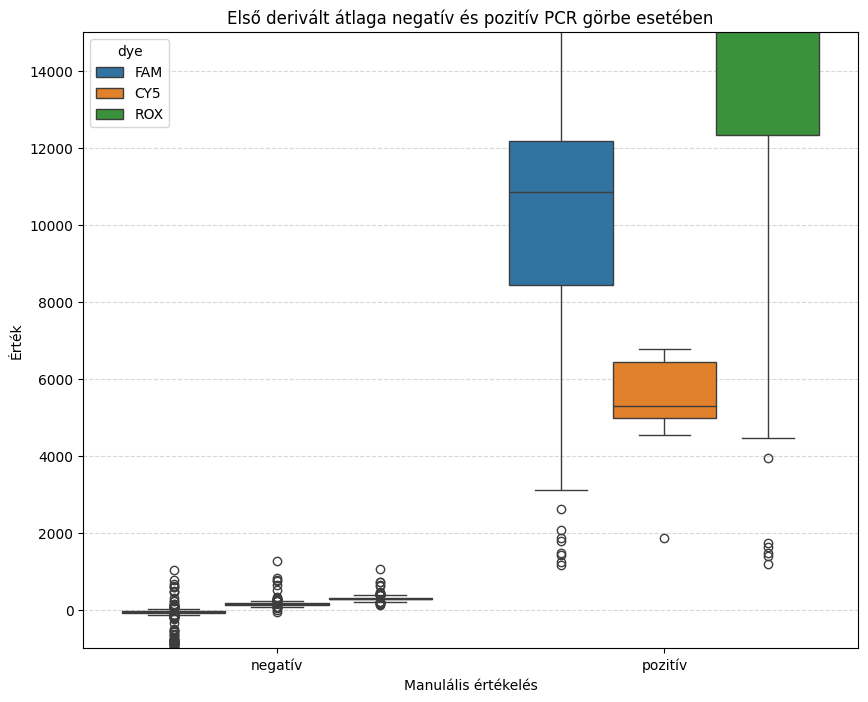

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.boxplot(data=all_manual_result_no_vic, x="manual_result", y="dy_mean", hue='dye')
plt.title("Első derivált átlaga negatív és pozitív PCR görbe esetében")
plt.xlabel("Manulális értékelés")
plt.ylabel("Érték")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ylim(-1000, 15000)
plt.show()

In [25]:
import plotly.express as px

fig = px.box(
    all_manual_result,
    x="manual_result",
    y="dy_mean",
    color="dye",
    color_discrete_map={
        "FAM": "#D75656",
        "ROX": "#7DA78C",
        "CY5": "#744577",
        "VIC": "#6594B1"
    }
)

fig.update_layout(
    template="simple_white",
    width=600,
    height=600,
    xaxis_title="Manuális értékelés",
    yaxis_title="Érték",
    yaxis=dict(
        range=[-1000, 14000],
        tickformat="d"   # <- teljes számok
    )
)

fig.update_layout(
    title=dict(
        text="Első derivált átlag eloszlása Légúti kitben csatornák szerint",
        x=0.5
    )
)

fig.add_hline(
    y=1100,
    line_dash="dash",
    line_color="gray",
    annotation_text="threshold",
    annotation_position="top left")

fig.add_shape(
    type="line",
    xref="paper",   # ← EZ A LÉNYEG
    x0=0,
    x1=1,
    yref="y",
    y0=1100,
    y1=1100,
    line=dict(color="gray", width=2, dash="dash"))


fig.show()

## Validálás02 - második derivált maximuma

In [26]:
import numpy as np
from scipy.signal import savgol_filter

 
def evaluate_sample_max(cycles,
                 fluorescence,
                 plateau_cycles: int = 10,
                 plateau_std_factor: float = 2.0,
                 dy_mean_threshold: float = 1000.0,
                 window: int = 9,
                 poly: int = 2) -> dict:

    y_smooth = savgol_filter(fluorescence, window, poly)
    dy_one = savgol_filter(y_smooth , window, poly, deriv=2)
    dy_max = dy_one.max()
    return dy_max

In [27]:
import pandas as pd

files = [covid_01, covid_02, covid_03, covid_04, covid_05, covid_06, covid_07, covid_08, covid_09, covid_10]

all_result_max = pd.DataFrame()
for file in files:
    df_max = eds_extract(file)
    rows = []
    channels = ["FAM", "VIC", "CY5", "ROX"]

    for wp in df_max['well_position'].unique():
        wp_df_max = df_max[df_max['well_position'] == wp]
        cycles = wp_df_max['cycle'][9:].values
        row = {'well_position': wp}
 
        for ch in channels:
            fluorescence = wp_df_max[ch][9:].values
            sample_result_max = evaluate_sample_max(cycles, fluorescence, window=9)
            row[ch] = sample_result_max
 
        rows.append(row)
 
    result_max = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
    result_max['PCR'] = file.split("\\")[-1].split(".")[0]
    all_result_max = pd.concat([all_result_max, result_max], ignore_index=True)

all_result_max.head()

,well_position,FAM,VIC,CY5,ROX,PCR
0,A1,89.916699,1251.587358,15.866982,58.486470,covid_01
1,A11,90.548940,1401.637085,19.373044,86.341204,covid_01
2,A13,98.319100,1306.619816,18.080574,73.174856,covid_01
3,A15,79.259862,1350.994106,10.852889,71.562761,covid_01
4,A17,89.807818,1269.142520,12.122561,74.901726,covid_01


In [28]:
all_result_max_melted = all_result_max.melt(id_vars=['PCR', 'well_position'], var_name='dye', value_name='dy_max')
all_result_max_melted.head()

,PCR,well_position,dye,dy_max
0,covid_01,A1,FAM,89.916699
1,covid_01,A11,FAM,90.548940
2,covid_01,A13,FAM,98.319100
3,covid_01,A15,FAM,79.259862
4,covid_01,A17,FAM,89.807818


In [29]:
all_manual_max_result = pd.merge(all_result_max_melted, manual_result_curves_melted, on=["PCR", "well_position", "dye"], how="left")
all_manual_max_result.head()

,PCR,well_position,dye,dy_max,manual_result
0,covid_01,A1,FAM,89.916699,negatív
1,covid_01,A11,FAM,90.548940,negatív
2,covid_01,A13,FAM,98.319100,negatív
3,covid_01,A15,FAM,79.259862,negatív
4,covid_01,A17,FAM,89.807818,negatív


In [30]:
all_manual_max_result_no_vic = all_manual_max_result[all_manual_max_result['dye'] != 'VIC']
all_manual_max_result_no_vic.head()

,PCR,well_position,dye,dy_max,manual_result
0,covid_01,A1,FAM,89.916699,negatív
1,covid_01,A11,FAM,90.548940,negatív
2,covid_01,A13,FAM,98.319100,negatív
3,covid_01,A15,FAM,79.259862,negatív
4,covid_01,A17,FAM,89.807818,negatív


In [31]:
import plotly.express as px

fig = px.box(
    all_manual_max_result,
    x="manual_result",
    y="dy_max",
    color="dye",
    color_discrete_map={
        "FAM": "#D75656",
        "VIC": "#6594B1",
        "ROX": "#7DA78C",
        "CY5": "#744577"
    }
)

fig.update_layout(
    template="simple_white",
    width=600,
    height=600,
    xaxis_title="Manuális értékelés",
    yaxis_title="Érték",
    yaxis=dict(
        range=[-1000, 14000],
        tickformat="d"   # <- teljes számok
    )
)

fig.update_layout(
    title=dict(
        text="Második derivált maximuma Légúti kitben csatornák szerint",
        x=0.5
    )
)

fig.show()

## HPV kit

### Első derivált átlag

In [32]:
from app.pcr.data_loader import eds_extract


hpv_1 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_1.eds"
hpv_2 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_2.eds"
hpv_3 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_3.eds"
hpv_4 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_4.eds"
hpv_5 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_5.eds"
hpv_6 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_6.eds"
hpv_7 = "C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\EDS_file\\HPV_teszt\\hpv_teszt_7.eds"
hpv_df = eds_extract(hpv_2)
hpv_df.to_excel("C:\\Users\\anett\\Downloads\\hpv_teszt_2.xlsx", index=False)
print(hpv_df.head())

dye  well well_position  cycle    CY5     FAM     VIC
0       1            A1      1  33294  365294  262174
1       1            A1      2  32800  362112  259326
2       1            A1      3  31772  356887  254004
3       1            A1      4  30616  347854  247097
4       1            A1      5  29532  336745  239351


In [33]:
import pandas as pd


hpv_files = [hpv_1, hpv_2, hpv_3, hpv_4, hpv_5, hpv_6, hpv_7]
#hpv_files = [hpv_3]

all_result_hpv = pd.DataFrame()
for hpv_file in hpv_files:
    df_hpv = eds_extract(hpv_file)
    rows = []
    channels = ["FAM", "VIC", "CY5"]

    for wp in df_hpv['well_position'].unique():
        wp_df = df_hpv[df_hpv['well_position'] == wp]
        cycles = wp_df['cycle'][9:].values
        row = {'well_position': wp}
 
        for ch in channels:
            fluorescence = wp_df[ch][9:].values
            sample_result = evaluate_sample_new(cycles, fluorescence, window=9)
            row[ch] = sample_result
 
        rows.append(row)
 
    result_hpv = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
    result_hpv['PCR'] = hpv_file.split("\\")[-1].split(".")[0]
    all_result_hpv = pd.concat([all_result_hpv, result_hpv], ignore_index=True)

all_result_hpv.head()
#all_result_hpv.to_excel("C:\\Users\\anett\\Downloads\\hpv_all.xlsx", index=False)

,well_position,FAM,VIC,CY5,PCR
0,A1,-115.592540,9559.730553,333.041545,hpv_teszt_1
1,A11,-191.774842,16.804564,4698.660089,hpv_teszt_1
2,A13,202.579321,11235.075068,520.109517,hpv_teszt_1
3,A15,15.528237,-26.968991,4551.419058,hpv_teszt_1
4,A17,-781.406693,8979.387175,159.595352,hpv_teszt_1


In [34]:
e7 = all_result_hpv[all_result_hpv['well_position'] == 'I21']
e7

,well_position,FAM,VIC,CY5,PCR
54,I21,130.251118,9546.292766,467.000814,hpv_teszt_1
150,I21,105.964825,4766.914167,2187.051157,hpv_teszt_2
246,I21,87.516293,9871.589006,904.824463,hpv_teszt_3
342,I21,108.506242,4827.087305,2650.600361,hpv_teszt_4
438,I21,59.251250,6687.775453,3093.522303,hpv_teszt_5
534,I21,13685.403342,26.185755,59.708947,hpv_teszt_6
630,I21,12912.227407,26.815416,55.411155,hpv_teszt_7


In [35]:
all_result_hpv_melted = all_result_hpv.melt(id_vars=['PCR', 'well_position'], var_name='dye', value_name='dy_mean')
all_result_hpv_melted.head()

,PCR,well_position,dye,dy_mean
0,hpv_teszt_1,A1,FAM,-115.592540
1,hpv_teszt_1,A11,FAM,-191.774842
2,hpv_teszt_1,A13,FAM,202.579321
3,hpv_teszt_1,A15,FAM,15.528237
4,hpv_teszt_1,A17,FAM,-781.406693


In [36]:
hpv_manual_result = pd.read_excel("C:\\Users\\anett\\OneDrive\\Dokumentumok\\SE-EMK\\III.felev\\Szakdolgozat\\Szakdolgozat\\260425_manulis_ertekeles_hpv.xlsx")
hpv_manual_result_curves = hpv_manual_result.drop(columns=["minta", "target"], axis=1)
hpv_manual_result_curves_melted = hpv_manual_result_curves.melt(id_vars=["well_position", "PCR"], var_name="dye", value_name="manual_result")
hpv_manual_result_curves_melted.head()


,well_position,PCR,dye,manual_result
0,A1,hpv_teszt_1,FAM,negatív
1,A11,hpv_teszt_1,FAM,negatív
2,A13,hpv_teszt_1,FAM,negatív
3,A15,hpv_teszt_1,FAM,negatív
4,A17,hpv_teszt_1,FAM,negatív


In [37]:
hpv_all_manual_result = pd.merge(all_result_hpv_melted, hpv_manual_result_curves_melted, on=["PCR", "well_position", "dye"], how="left")
hpv_all_manual_result.head()

,PCR,well_position,dye,dy_mean,manual_result
0,hpv_teszt_1,A1,FAM,-115.592540,negatív
1,hpv_teszt_1,A11,FAM,-191.774842,negatív
2,hpv_teszt_1,A13,FAM,202.579321,negatív
3,hpv_teszt_1,A15,FAM,15.528237,negatív
4,hpv_teszt_1,A17,FAM,-781.406693,negatív


In [38]:
import plotly.express as px

fig = px.box(
    hpv_all_manual_result,
    x="manual_result",
    y="dy_mean",
    color="dye",
    color_discrete_map={
        "FAM": "#D75656",
        "VIC": "#7DA78C",
        "CY5": "#744577"
    }
)

fig.update_layout(
    template="simple_white",
    width=600,
    height=600,
    title=dict(text="Első derivált átlaga Légúti panel kitben csatornák szerint", x=0.5),
    xaxis_title="Manuális értékelés",
    yaxis_title="Érték",
    yaxis=dict(
        range=[-1000, 14000],
        tickformat="d"   # <- teljes számok
    )
)

fig.update_layout(
    title=dict(
        text="Első derivált átlag eloszlása HPV kitben csatornák szerint",
        x=0.5
    )
)

fig.add_hline(
    y=1100,
    line_dash="dash",
    line_color="gray",
    annotation_text="threshold",
    annotation_position="top left")

fig.add_shape(
    type="line",
    xref="paper",   # ← EZ A LÉNYEG
    x0=0,
    x1=1,
    yref="y",
    y0=1100,
    y1=1100,
    line=dict(color="gray", width=2, dash="dash"))


fig.show()

In [39]:
import pandas as pd

hpv_files = [hpv_1, hpv_2, hpv_3, hpv_4, hpv_5, hpv_6, hpv_7]

all_result_max_hpv = pd.DataFrame()
for hpv_file in hpv_files:
    df_hpv_max = eds_extract(hpv_file)
    rows = []
    channels = ["FAM", "VIC", "CY5"]

    for wp in df_hpv['well_position'].unique():
        wp_df = df_hpv_max[df_hpv_max['well_position'] == wp]
        cycles = wp_df['cycle'][9:].values
        row = {'well_position': wp}
 
        for ch in channels:
            fluorescence = wp_df[ch][9:].values
            sample_result = evaluate_sample_max(cycles, fluorescence, window=9)
            row[ch] = sample_result
 
        rows.append(row)
 
    result_hpv_max = pd.DataFrame(rows).sort_values('well_position').reset_index(drop=True)
    result_hpv_max['PCR'] = hpv_file.split("\\")[-1].split(".")[0]
    all_result_max_hpv = pd.concat([all_result_max_hpv, result_hpv_max], ignore_index=True)

all_result_max_hpv.head()


,well_position,FAM,VIC,CY5,PCR
0,A1,355.276817,5673.756311,138.040320,hpv_teszt_1
1,A11,165.993553,27.267030,3630.918723,hpv_teszt_1
2,A13,36.998773,6417.431457,180.292189,hpv_teszt_1
3,A15,156.579342,274.734586,3578.747953,hpv_teszt_1
4,A17,906.269396,5852.181078,232.114316,hpv_teszt_1


In [40]:
all_result_max_hpv_melted = all_result_max_hpv.melt(id_vars=['PCR', 'well_position'], var_name='dye', value_name='dy_max')
all_result_max_hpv_melted.head()

,PCR,well_position,dye,dy_max
0,hpv_teszt_1,A1,FAM,355.276817
1,hpv_teszt_1,A11,FAM,165.993553
2,hpv_teszt_1,A13,FAM,36.998773
3,hpv_teszt_1,A15,FAM,156.579342
4,hpv_teszt_1,A17,FAM,906.269396


In [41]:
hpv_all_manual_max_result = pd.merge(all_result_max_hpv_melted, hpv_manual_result_curves_melted, on=["PCR", "well_position", "dye"], how="left")
hpv_all_manual_max_result.head()

,PCR,well_position,dye,dy_max,manual_result
0,hpv_teszt_1,A1,FAM,355.276817,negatív
1,hpv_teszt_1,A11,FAM,165.993553,negatív
2,hpv_teszt_1,A13,FAM,36.998773,negatív
3,hpv_teszt_1,A15,FAM,156.579342,negatív
4,hpv_teszt_1,A17,FAM,906.269396,negatív


In [42]:
import plotly.express as px

fig = px.box(
    hpv_all_manual_max_result,
    x="manual_result",
    y="dy_max",
    color="dye",
    color_discrete_map={
        "FAM": "#D75656",
        "VIC": "#7DA78C",
        "CY5": "#744577"
    }
)

fig.update_layout(
    template="simple_white",
    width=600,
    height=600,
    title=dict(text="Első derivált átlaga a HPV kitben csatornál szerint", x=0.5),
    xaxis_title="Manuális értékelés",
    yaxis_title="Érték",
    yaxis=dict(
        range=[-1000, 14000],
        tickformat="d"   
    )
)

fig.update_layout(
    title=dict(
        text="Második derivált maximum eloszlása a HPV kitben csatornák szerint",
        x=0.5
    )
)

#fig.add_hline(
    #y=1000,
    #line_dash="dash",
    #line_color="gray",
    #annotation_text="threshold",
    #annotation_position="top left")

#fig.add_shape(
    #type="line",
    #xref="paper",   # ← EZ A LÉNYEG
    #x0=0,
    #x1=1,
    #yref="y",
    #y0=1000,
    #y1=1000,
    #line=dict(color="gray", width=2, dash="dash"))


fig.show()